In [112]:
import pandas as pd
import matplotlib.pyplot as pit

# Đọc file
df = pd.read_csv('../api/used_cars.csv')
df


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [ ]:
from sklearn.preprocessing import LabelEncoder
import re

# Xử lý giá tiền của xe từ chuỗi thành số

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# Xử lý số dặm xe đã đi

df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(int)
)

df['milage']

# Thêm cột "age" để biểu diễn số tuổi của chiếc xe

df['age'] = 2026 - df['model_year']

# Chuyển đổi nhiên liệu thành dạng dữ liệu để phân tích (Label endcoding)

le = LabelEncoder()
df['fuel_type'] = le.fit_transform(df['fuel_type'])

# Thêm cột horsepower để biểu diễn số mã lực dựa trên cột "engine" của chiếc xe

df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,horsepower
0,Ford,Utility Police Interceptor Base,2013,51000,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0
1,Hyundai,Palisade SEL,2021,34742,2,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,NaN
2,Lexus,RX 350 RX 350,2022,22372,2,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598,4,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,2,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999,5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714,2,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,349950,3,NaN
4005,Audi,S4 3.0T Premium Plus,2022,10900,2,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,53900,4,349.0
4006,Porsche,Taycan,2022,2116,7,Electric,Automatic,Black,Black,None reported,NaN,90998,4,NaN
4007,Ford,F-150 Raptor,2020,33000,2,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,62999,6,450.0


In [114]:
# Số lượng giá trị null

df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
age               0
horsepower      808
dtype: int64

In [115]:
# Xóa các hàng có các giá trị là null hoặc không có giá trị

df = df.dropna(axis=0)

In [116]:
# Kiểm tra lại các giá trị null hoặc không có giá trị

df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
age             0
horsepower      0
dtype: int64

In [117]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,fuel_type,price,age,horsepower
count,3116.000000,3116.000000,3116.000000,3.116000e+03,3116.000000,3116.000000
mean,2014.643132,71883.474968,2.180039,3.860767e+04,11.356868,331.445122
std,5.877376,53504.251954,1.141652,7.011366e+04,5.877376,121.362582
min,1996.000000,100.000000,0.000000,2.000000e+03,2.000000,70.000000
25%,2011.000000,29685.750000,2.000000,1.548375e+04,7.000000,248.000000
50%,2016.000000,62661.000000,2.000000,2.800000e+04,10.000000,310.000000
75%,2019.000000,102428.500000,2.000000,4.700000e+04,15.000000,400.000000
max,2024.000000,405000.000000,7.000000,2.954083e+06,30.000000,1020.000000


In [118]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,horsepower
0,Ford,Utility Police Interceptor Base,2013,51000,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0
6,Audi,S3 2.0T Premium Plus,2017,84000,2,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,9,292.0
7,BMW,740 iL,2001,242000,2,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,25,282.0
8,Lexus,RC 350 F Sport,2021,23436,2,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927,5,311.0


In [119]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,fuel_type,price,age,horsepower
count,3116.000000,3116.000000,3116.000000,3.116000e+03,3116.000000,3116.000000
mean,2014.643132,71883.474968,2.180039,3.860767e+04,11.356868,331.445122
std,5.877376,53504.251954,1.141652,7.011366e+04,5.877376,121.362582
min,1996.000000,100.000000,0.000000,2.000000e+03,2.000000,70.000000
25%,2011.000000,29685.750000,2.000000,1.548375e+04,7.000000,248.000000
50%,2016.000000,62661.000000,2.000000,2.800000e+04,10.000000,310.000000
75%,2019.000000,102428.500000,2.000000,4.700000e+04,15.000000,400.000000
max,2024.000000,405000.000000,7.000000,2.954083e+06,30.000000,1020.000000


Index(['BMW', 'Ford', 'Mercedes-Benz', 'Chevrolet', 'Toyota'], dtype='str', name='brand')


Text(0.5, 1.0, 'Biểu đồ số lượng xe các năm của các hãng top đầu')

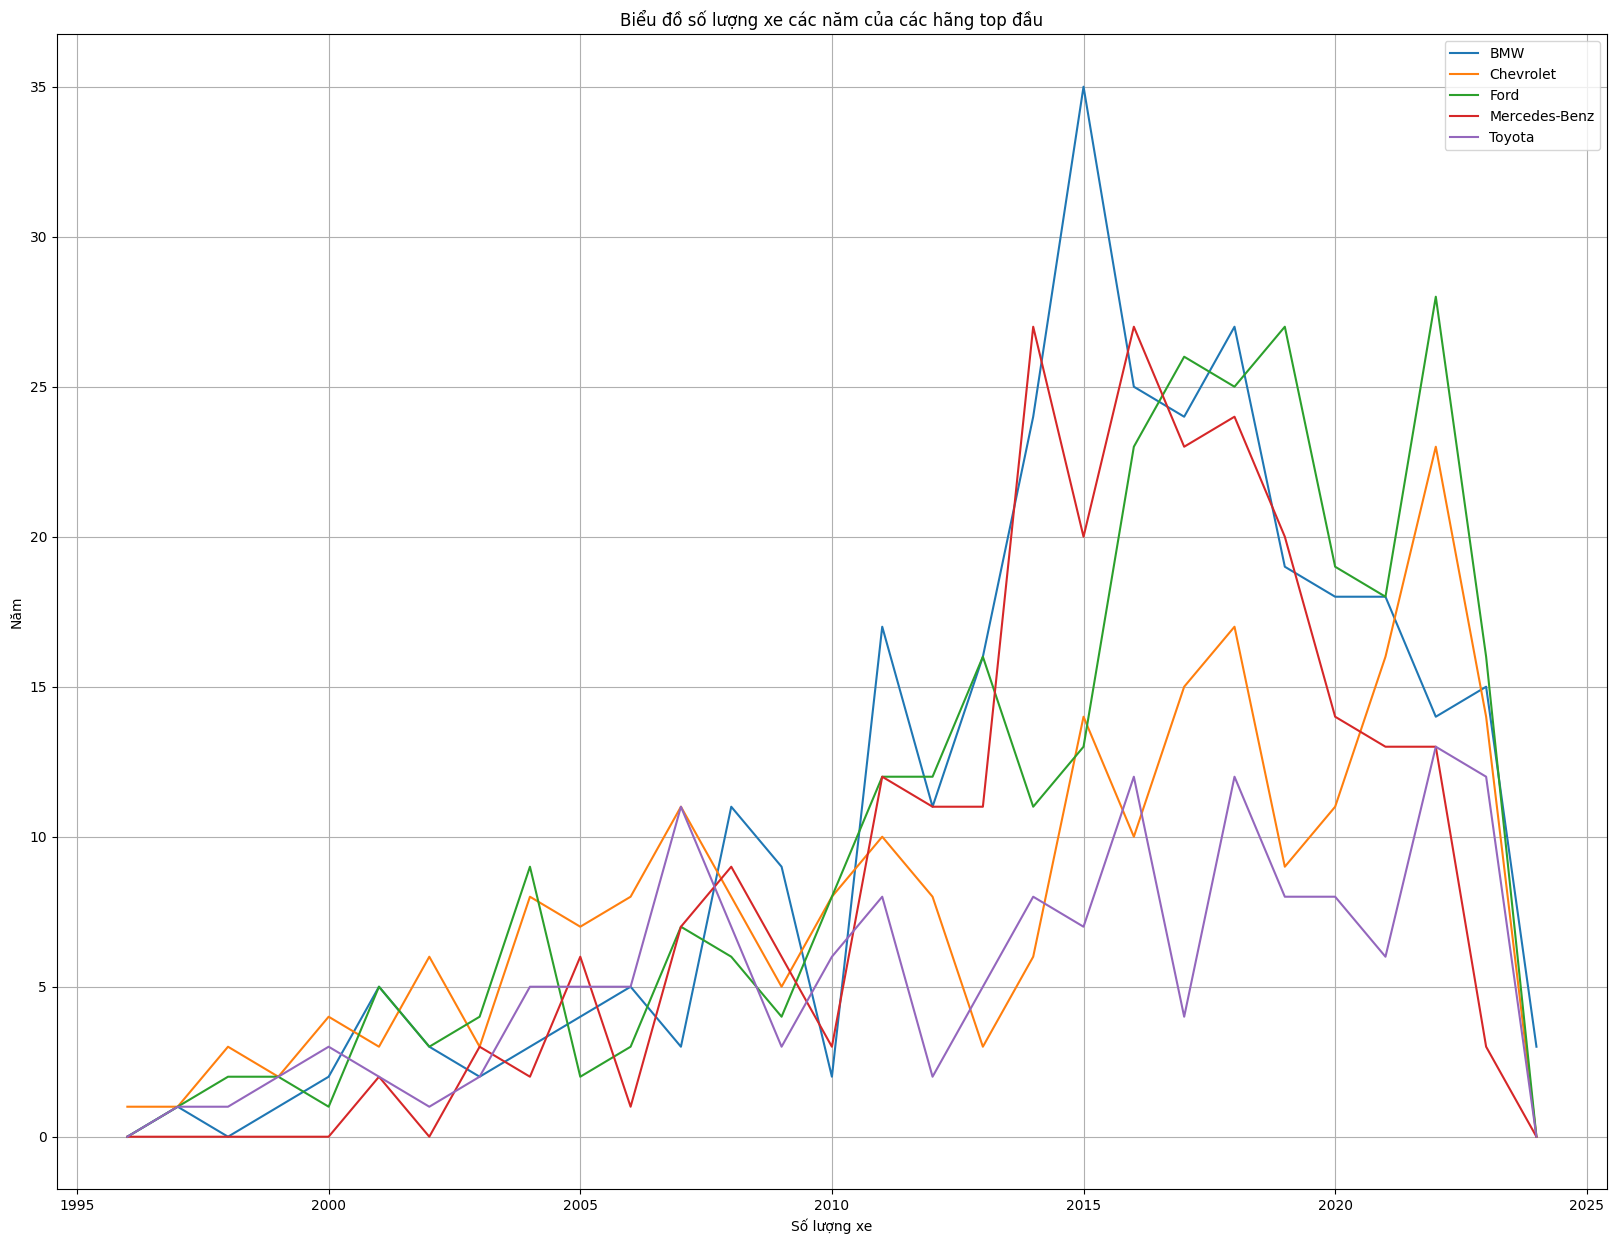

In [120]:
# Biều đồ đường: Dùng để biểu diễn tổng số xe của hãng đó trong các năm

top_brand = df['brand'].value_counts().head().index

print(top_brand)
df_top_brand = df[df['brand'].isin(top_brand)]
pivot_df = df_top_brand.pivot_table(index='model_year', columns='brand', values='model', aggfunc='count', fill_value=0)

pit.figure(figsize=(20, 15))
for brand in pivot_df.columns:
    pit.plot(pivot_df.index, pivot_df[brand], label=brand)

pit.xlabel('Số lượng xe')
pit.ylabel('Năm')
pit.legend()
pit.grid()
pit.title('Biểu đồ số lượng xe các năm của các hãng top đầu')

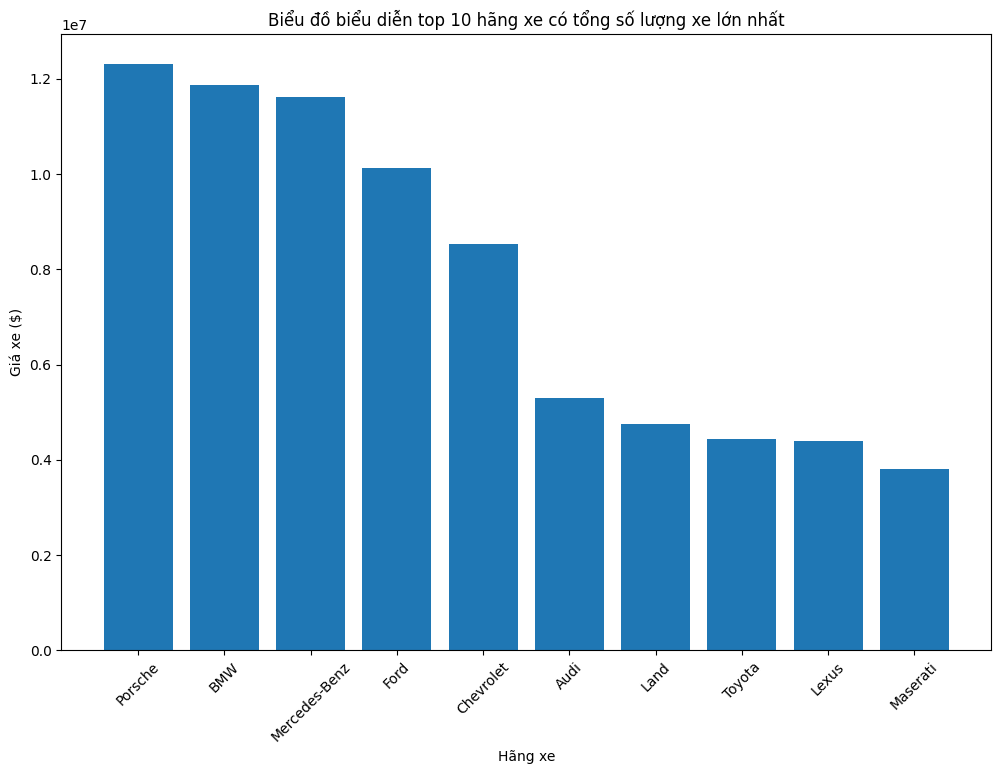

In [121]:
# Biểu đồ cột: Dùng để biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất

df_sum_brand = df[['brand', 'price']].groupby('brand').sum()
df_sum_brand = df_sum_brand.sort_values(by='price', ascending=False).head(10)
df_sum_brand

pit.figure(figsize=(12, 8))
pit.bar(x=df_sum_brand.index, height=df_sum_brand['price'])
pit.xticks(rotation=45)
pit.title('Biểu đồ biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất')
pit.xlabel('Hãng xe')
pit.ylabel('Giá xe ($)')
pit.show()


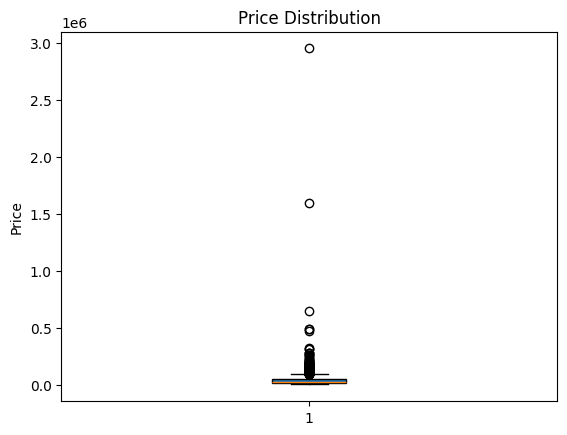

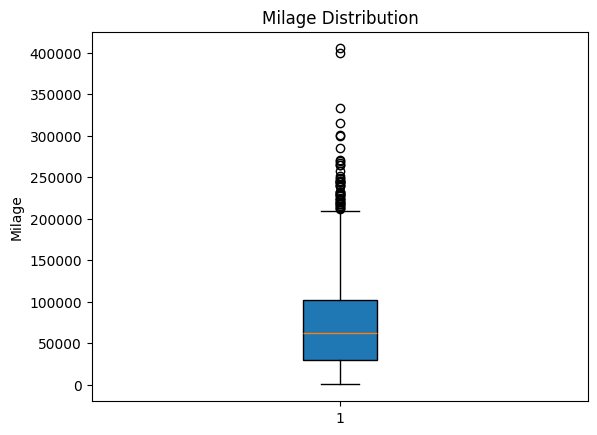

In [122]:
# Biều đồ biểu thị giá trị ngoại lai (Box plot)

pit.boxplot(df['price'], patch_artist=True)
pit.title("Price Distribution")
pit.ylabel("Price")
pit.show()

pit.boxplot(df['milage'], patch_artist=True)
pit.title("Milage Distribution")
pit.ylabel("Milage")
pit.show()


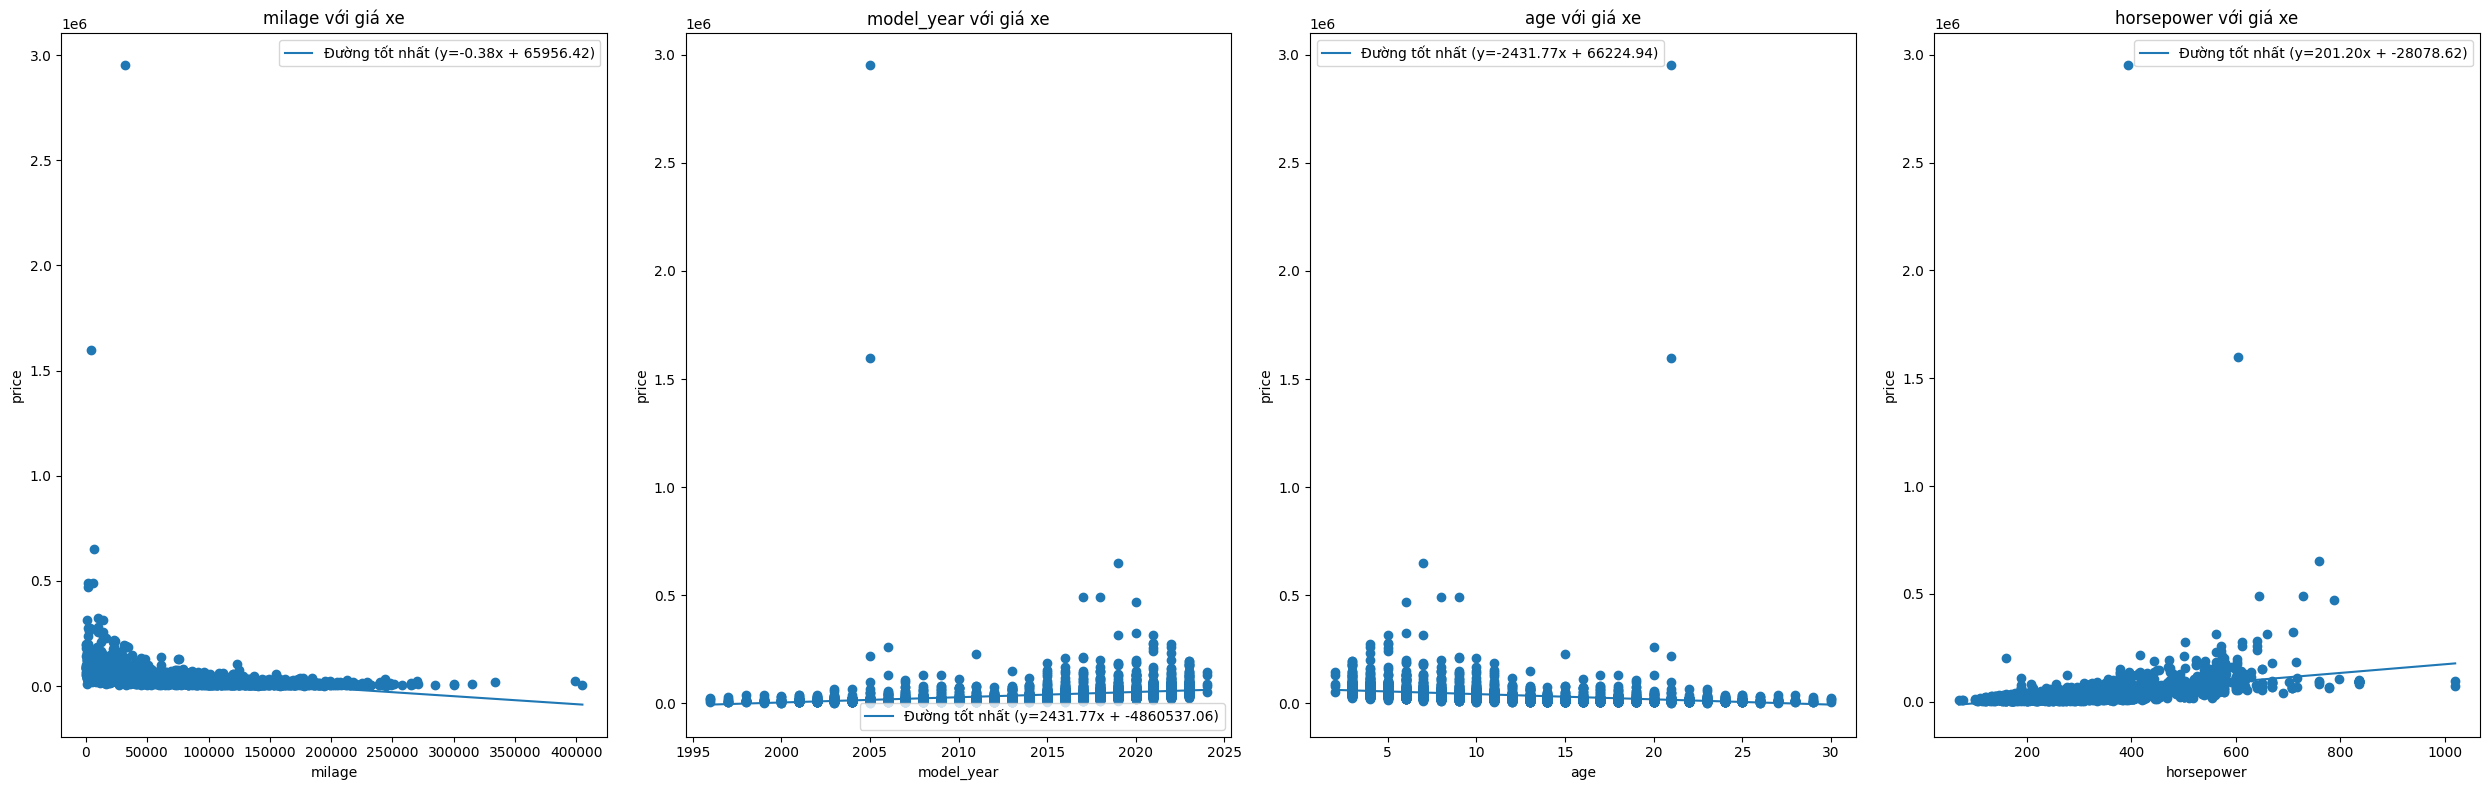

In [123]:
import numpy as np

# Biểu đồ biểu diễn mối quan hệ giữa số km đi, số năm sản suất, màu và giá xe

features = ['milage', 'model_year', 'age', 'horsepower']
target = 'price'

pit.figure(figsize=(25, 8))
for i, col in enumerate(features):
    x = df[col]
    y = df[target]

    pit.subplot(1, 4, i + 1)
    a, b = np.polyfit(x, y, 1)
    pit.scatter(df[col], df[target])
    sort_idx = np.argsort(x)
    pit.plot(x.iloc[sort_idx], (a * x + b).iloc[sort_idx], label=f'Đường tốt nhất (y={a:.2f}x + {b:.2f})')
    pit.xlabel(col)
    pit.ylabel(target)
    pit.title(f'{col} với giá xe')
    pit.legend()

pit.tight_layout()
pit.show()